
4.6 Project - edwgol5635 - 02/22/2026


In [1]:

# Load the dataset 
import pandas as pd

file_path = 'C:\\Files\\Excel\\Project\\Happiness_Development_Index.xlsx'

# Load worksheet
df_raw = pd.read_excel(file_path, sheet_name='HDI')
print('Loaded shape:', df_raw.shape)
df_raw.head()


Loaded shape: (190, 7)


,HDI Rank,Country,Human Development Index (HDI),Life expectancy at birth,Expected years of schooling,Mean years of schooling,Gross national income (GNI) per capita
0,1,Switzerland,0.962,83.9872,16.500299,13.85966,66933.00454
1,2,Norway,0.961,83.2339,18.185200,13.00363,64660.10622
2,3,Iceland,0.959,82.6782,19.163059,13.76717,55782.04981
3,4,"Hong Kong, China (SAR)",0.952,85.4734,17.278170,12.22621,62606.84540
4,5,Australia,0.951,84.5265,21.054590,12.72682,49238.43335


In [2]:

# Prepare columns basic cleaning 
import numpy as np

cols_map = {
    'Human Development Index (HDI) ': 'HDI',
    'Human Development Index (HDI)': 'HDI',
    'Life expectancy at birth': 'life_expectancy',
    'Expected years of schooling': 'expected_schooling',
    'Mean years of schooling': 'mean_schooling',
    'Gross national income (GNI) per capita': 'gni_per_capita'
}

df = df_raw.rename(columns=cols_map)

needed = ['HDI','life_expectancy','expected_schooling','mean_schooling','gni_per_capita']
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Identify categorical object columns 
cat_cols = [c for c in df.columns if df[c].dtype == 'object' and c not in ['HDI']]
print('Categorical columns detected:', cat_cols)

# drop rows with missing required fields
df_subset = df[needed + cat_cols].copy()
rows_before = len(df_subset)
df_subset = df_subset.dropna(subset=needed)
print(f"Dropped {rows_before - len(df_subset)} rows with NA in required fields")

# Simple validity clamps to avoid negative inputs 
for c in ['life_expectancy','expected_schooling','mean_schooling','gni_per_capita']:
    df_subset[c] = pd.to_numeric(df_subset[c], errors='coerce').clip(lower=0)

print('Prepared shape:', df_subset.shape)
df_subset.head()


Categorical columns detected: []
Dropped 0 rows with NA in required fields
Prepared shape: (190, 5)


,HDI,life_expectancy,expected_schooling,mean_schooling,gni_per_capita
0,0.962,83.9872,16.500299,13.85966,66933.00454
1,0.961,83.2339,18.185200,13.00363,64660.10622
2,0.959,82.6782,19.163059,13.76717,55782.04981
3,0.952,85.4734,17.278170,12.22621,62606.84540
4,0.951,84.5265,21.054590,12.72682,49238.43335


In [3]:

# One-hot encode categorical columns (
import pandas as pd

df_encoded = pd.get_dummies(df_subset, columns=[c for c in df_subset.columns if df_subset[c].dtype=='object'], drop_first=True)
print('Encoded shape:', df_encoded.shape)
df_encoded.head()


Encoded shape: (190, 5)


,HDI,life_expectancy,expected_schooling,mean_schooling,gni_per_capita
0,0.962,83.9872,16.500299,13.85966,66933.00454
1,0.961,83.2339,18.185200,13.00363,64660.10622
2,0.959,82.6782,19.163059,13.76717,55782.04981
3,0.952,85.4734,17.278170,12.22621,62606.84540
4,0.951,84.5265,21.054590,12.72682,49238.43335


In [4]:

#Train/test split 70/30
from sklearn.model_selection import train_test_split

feature_cols = ['life_expectancy','expected_schooling','mean_schooling','gni_per_capita']
X = df_encoded[feature_cols]
y = df_encoded['HDI']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print('Train:', X_train.shape, y_train.shape)
print('Test:', X_test.shape, y_test.shape)


Train: (133, 4) (133,)
Test: (57, 4) (57,)


In [5]:

# Train Linear Regression 
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train, y_train)

print('Intercept:', linreg.intercept_)
print('Coefficients :', dict(zip(X_train.columns, linreg.coef_)))


Intercept: -0.050628452276883174
Coefficients : {'life_expectancy': np.float64(0.005868280500319557), 'expected_schooling': np.float64(0.012360570458971371), 'mean_schooling': np.float64(0.017782254610411174), 'gni_per_capita': np.float64(1.3254568188396376e-06)}


In [6]:

# Predictions
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

preds = linreg.predict(X_test)
mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
r2  = r2_score(y_test, preds)

print(f"MAE: {mae:.6f}")
print(f"MSE: {mse:.6f}")
print(f"R-squared: {r2:.6f}")


MAE: 0.016027
MSE: 0.000565
R-squared: 0.970315


In [7]:

# Feature importance 
import pandas as pd

coef_series = pd.Series(linreg.coef_, index=X_train.columns)
feat_importance = coef_series.abs().sort_values(ascending=False)
print('Feature importance:')
print(feat_importance)


Feature importance:
mean_schooling        0.017782
expected_schooling    0.012361
life_expectancy       0.005868
gni_per_capita        0.000001
dtype: float64


FINAL PROJECT ANALYSIS - 
Given the variables asked of, 
Mean years of schooling can be actionable can be actionable with govermental policies that directlky benefit education. Education can directly effect A countries happiness by giving the ability of knowledge to make better decisons to exapands ones persdonal life for the better, but as well as ones community. This directly correlates with expected years of schooling. The more years a person paasses through directly effects their knowledge and analytical reasoning skills. The more people in a country that have obtained the highest number years educated will deffinitly tend to be higher than those of lower. 

Life expectancy can be actionable in the sense that just as well as a countries education policies, they can also make policies that can directly effect thge publics health. Mandated vaccines, healthcare access, disease prevention, clean water, and even control of alcohol and tobaco can all play part in exteding a countries life expectancy. 



In [8]:
# --- 1) Point to YOUR file & sheet (edit the path if needed) ---
from pathlib import Path
import pandas as pd
import numpy as np

excel_path = r"C:\Files\Excel\Project\Happiness_Development_Index.xlsx"  # <-- your path
sheet_name = "HDI"                                                       # <-- your sheet

print("Path exists? ->", Path(excel_path).exists(), "| sheet:", sheet_name)

# --- 2) Expected columns (we'll normalize headers & auto-match if labels vary slightly) ---
HDI_COL           = "Human Development Index (HDI)"
LIFEEXP_COL       = "Life expectancy at birth"
EXPECTED_SCH_COL  = "Expected years of schooling"
MEAN_SCH_COL      = "Mean years of schooling"
GNI_COL           = "Gross national income (GNI) per capita"

def normalize_headers(df):
    df = df.copy()
    df.columns = (df.columns.astype(str)
                  .str.replace(r'[\u00A0\u202F\u2007]', ' ', regex=True)  # replace NBSP variants
                  .str.replace(r'\s+', ' ', regex=True)                  # collapse runs of spaces
                  .str.strip())
    return df

# --- 3) Read your sheet and normalize column names ---
df_master = pd.read_excel(excel_path, sheet_name=sheet_name, engine="openpyxl")
df_master = normalize_headers(df_master)

# If the worksheet has a title row above the true headers, auto-detect a header row containing "Country"
if 'Country' not in df_master.columns:
    raw = pd.read_excel(excel_path, sheet_name=sheet_name, header=None, engine="openpyxl")
    possible = raw.apply(lambda r: r.astype(str).str.contains(r'^\s*Country\s*$', case=False, na=False), axis=1)
    if not possible.any():
        possible = raw.apply(lambda r: r.astype(str).str.contains('country', case=False, na=False), axis=1)
    header_row = int(possible.idxmax())
    df_master = pd.read_excel(excel_path, sheet_name=sheet_name, header=header_row, engine="openpyxl")
    df_master = normalize_headers(df_master)
else:
    header_row = "already headered"

# --- 4) Resolve the HDI column name if it differs slightly ---
if HDI_COL not in df_master.columns:
    hdi_candidates = [c for c in df_master.columns
                      if 'human development index' in c.lower() or c.strip().lower() in ('hdi','hdi index')]
    if hdi_candidates:
        HDI_COL = hdi_candidates[0]
    else:
        raise KeyError("HDI column not found. Available columns:\n" + "\n".join(map(repr, df_master.columns)))

# --- 5) Set and verify model feature columns (adjust here if your headers differ) ---
FEATURE_COLUMNS = [LIFEEXP_COL, EXPECTED_SCH_COL, MEAN_SCH_COL, GNI_COL]
missing = [c for c in FEATURE_COLUMNS if c not in df_master.columns]
if missing:
    hints = {m: [c for c in df_master.columns if m.lower() in c.lower()] for m in missing}
    raise KeyError("Missing feature columns: " + ", ".join(missing) +
                   "\nClose matches:\n" + "\n".join(f"{k}: {v}" for k,v in hints.items()))

# --- 6) Keep only rows with all needed values ---
df_master = df_master.dropna(subset=FEATURE_COLUMNS + [HDI_COL]).copy()

# --- 7) Create a simple linear model ONLY if you don't already have one in memory ---
if 'model' not in globals():
    X = df_master[FEATURE_COLUMNS].to_numpy(float)
    y = df_master[HDI_COL].to_numpy(float)
    Xd = np.c_[np.ones(len(X)), X]                 # add intercept
    beta, *_ = np.linalg.lstsq(Xd, y, rcond=None)  # least squares
    intercept_, coef_ = float(beta[0]), beta[1:]

    class SimpleLinearModel:
        def __init__(self, coef, intercept, feature_names):
            self.coef_ = np.array(coef, dtype=float)
            self.intercept_ = float(intercept)
            self.feature_names_ = list(feature_names)
        def predict(self, X_df):
            Xm = X_df[self.feature_names_].to_numpy(dtype=float)
            return Xm @ self.coef_ + self.intercept_

    model = SimpleLinearModel(coef_, intercept_, FEATURE_COLUMNS)

# --- 8) Canonical dataframe used by the rest of the notebook ---
df_all = df_master.copy()

print("Header row used:", header_row)
print("Using HDI column:", HDI_COL)
print("FEATURE_COLUMNS:", FEATURE_COLUMNS)
print("df_all shape:", df_all.shape)

Path exists? -> True | sheet: HDI
Header row used: already headered
Using HDI column: Human Development Index (HDI)
FEATURE_COLUMNS: ['Life expectancy at birth', 'Expected years of schooling', 'Mean years of schooling', 'Gross national income (GNI) per capita']
df_all shape: (190, 7)


In [9]:
# Uses df_all, FEATURE_COLUMNS, model from your loader cell
HDI_COL = "Human Development Index (HDI)"
LIFEEXP_COL = "Life expectancy at birth"
MEAN_SCH_COL = "Mean years of schooling"

PRED_HDI_COL = "Predicted HDI"
PRED_HDI_AFTER_COL = "Predicted HDI after intervention"

import numpy as np
import pandas as pd

def predict_hdi(X):
    return pd.Series(model.predict(X[FEATURE_COLUMNS]), index=X.index)

# Baseline predictions
df_all[PRED_HDI_COL] = predict_hdi(df_all)

# Below-median subset by observed HDI
median_hdi = df_all[HDI_COL].median()
subset_mask = df_all[HDI_COL] < median_hdi

# Apply policy interventions on a copy of the features
X_after = df_all[FEATURE_COLUMNS].copy()
X_after.loc[subset_mask, LIFEEXP_COL] = X_after.loc[subset_mask, LIFEEXP_COL] * 1.05    # +5%
X_after.loc[subset_mask, MEAN_SCH_COL] = X_after.loc[subset_mask, MEAN_SCH_COL] + 1.5   # +1.5 years

# Predict after-intervention
after_pred = predict_hdi(X_after)

# Store results
df_all[PRED_HDI_AFTER_COL] = df_all[PRED_HDI_COL]
df_all.loc[subset_mask, PRED_HDI_AFTER_COL] = after_pred.loc[subset_mask]

# Summary
before_mean = df_all.loc[subset_mask, PRED_HDI_COL].mean()
after_mean = df_all.loc[subset_mask, PRED_HDI_AFTER_COL].mean()
abs_change = after_mean - before_mean
rel_change = abs_change / before_mean if before_mean else np.nan

print("Below-median group size:", int(subset_mask.sum()))
print(f"Mean predicted HDI BEFORE: {before_mean:.4f}")
print(f"Mean predicted HDI AFTER : {after_mean:.4f}")
print(f"Absolute change          : {abs_change:+.4f}")
print(f"Relative change          : {rel_change:+.2%}")

# (Optional) Show top 10 countries by improvement if a 'Country' column exists
if 'Country' in df_all.columns:
    tmp = df_all.loc[subset_mask, ['Country', PRED_HDI_COL, PRED_HDI_AFTER_COL]].copy()
    tmp['Δ_pred_HDI'] = tmp[PRED_HDI_AFTER_COL] - tmp[PRED_HDI_COL]
    display(tmp.sort_values('Δ_pred_HDI', ascending=False).head(10))

Below-median group size: 95
Mean predicted HDI BEFORE: 0.6016
Mean predicted HDI AFTER : 0.6498
Absolute change          : +0.0482
Relative change          : +8.01%


,Country,Predicted HDI,Predicted HDI after intervention,Δ_pred_HDI
112,Lebanon,0.700007,0.751130,0.051124
102,Jordan,0.718694,0.769568,0.050874
127,Cabo Verde,0.662583,0.713392,0.050809
123,Morocco,0.677501,0.728307,0.050806
125,Nicaragua,0.677431,0.728173,0.050741
97,Tunisia,0.722894,0.773615,0.050721
114,Viet Nam,0.704664,0.755337,0.050672
105,"Palestine, State of",0.736469,0.787096,0.050627
101,Dominica,0.703661,0.754080,0.050419
110,Samoa,0.745392,0.795796,0.050404


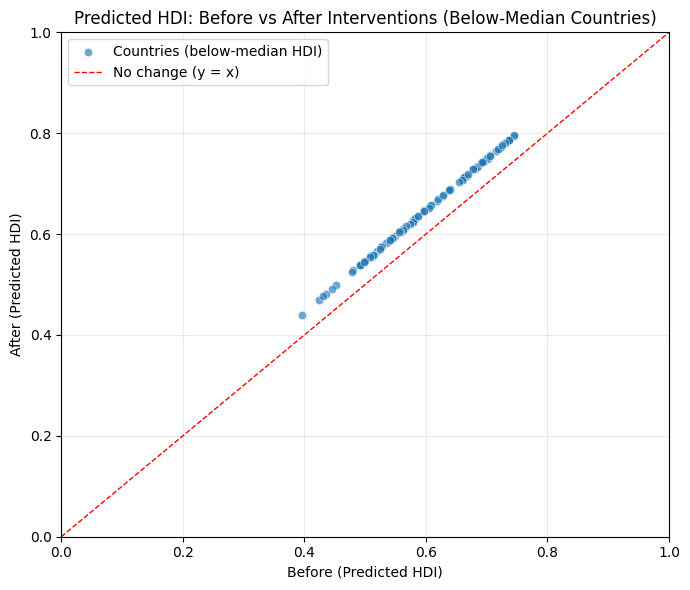

In [10]:
import matplotlib.pyplot as plt

subset = df_all[df_all[HDI_COL] < df_all[HDI_COL].median()]
x = subset["Predicted HDI"].values
y = subset["Predicted HDI after intervention"].values

plt.figure(figsize=(7,6))
plt.scatter(x, y, alpha=0.65, color="#1f77b4", edgecolor="white", linewidth=0.5,
            label="Countries (below-median HDI)")
lims = [min(x.min(), y.min(), 0), max(x.max(), y.max(), 1)]
plt.plot(lims, lims, 'r--', linewidth=1, label='No change (y = x)')
plt.xlim(lims); plt.ylim(lims)
plt.title("Predicted HDI: Before vs After Interventions (Below-Median Countries)")
plt.xlabel("Before (Predicted HDI)")
plt.ylabel("After (Predicted HDI)")
plt.grid(alpha=0.25); plt.legend(); plt.tight_layout(); plt.show()

In [11]:
# A) By baseline HDI quartiles (subset only)
subset = df_all[df_all[HDI_COL] < df_all[HDI_COL].median()].copy()
subset['Δ_pred_HDI'] = subset["Predicted HDI after intervention"] - subset["Predicted HDI"]
subset['Baseline HDI quartile'] = pd.qcut(subset[HDI_COL], q=4, labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'])

quartile_summary = (subset
    .groupby('Baseline HDI quartile', observed=True)['Δ_pred_HDI']
    .agg(['count','mean','median','max'])
    .rename(columns={'count':'n', 'mean':'avg gain', 'median':'median gain', 'max':'max gain'}))
display(quartile_summary)

# B) By baseline Life Expectancy and Mean Schooling bands (subset only)
subset['LE band'] = pd.cut(subset[LIFEEXP_COL], bins=[0,65,75,90], labels=['<65','65–75','>75'])
subset['Schooling band'] = pd.cut(subset[MEAN_SCH_COL], bins=[0,8,12,20], labels=['<8 yrs','8–12 yrs','>12 yrs'])

band_summary = (subset
    .groupby(['LE band','Schooling band'], observed=True)['Δ_pred_HDI']
    .agg(['count','mean','median','max'])
    .sort_values('mean', ascending=False))
display(band_summary)

# C) (Optional) How many cross illustrative thresholds
for thr in (0.55, 0.70, 0.80):
    crossed = ((subset["Predicted HDI"] < thr) & (subset["Predicted HDI after intervention"] >= thr)).sum()
    print(f"Countries crossing {thr:.2f} after intervention: {crossed}")

,n,avg gain,median gain,max gain
Baseline HDI quartile,,,,
Q1 (lowest),25,0.046660,0.046871,0.048613
Q2,23,0.047455,0.047452,0.050181
Q3,23,0.049274,0.049650,0.050809
Q4 (highest),24,0.049457,0.049653,0.051124


count      mean    median       max
LE band Schooling band                                     
>75     8–12 yrs            1  0.051124  0.051124  0.051124
65–75   8–12 yrs           22  0.049594  0.049683  0.050874
        <8 yrs             30  0.049322  0.049344  0.050809
<65     8–12 yrs            6  0.047147  0.047316  0.047809
        <8 yrs             36  0.046485  0.046685  0.047944

Countries crossing 0.55 after intervention: 17
Countries crossing 0.70 after intervention: 18
Countries crossing 0.80 after intervention: 0
